### <u>Initial data inspection and data cleaning:</u>

##### Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. Check for any instances of erroneous entries and rectify them as needed

In [359]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

df = pd.read_csv('rolling_stones_spotify.csv', index_col=0)

In [360]:
df.duplicated().sum()

0

No two rows are exactly the same, but this is because each song has it's own unique ID. There may still be rows that represent the same song or slightly different variations.

In [361]:
group_sizes = df.groupby(['name', 'duration_ms']).size()
duplicated_songs = group_sizes[group_sizes >= 2]
duplicated_songs.value_counts()

2    133
3     39
Name: count, dtype: int64

If we look for duplicates based on name and duration, we find that there are 133 songs that appear twice, and 39 that appear 3 times. These are songs with exact same name and durations. In practice, this may not catch all actual duplicates. Normalizing songs such as removing suffixes like " - Live", "(Bonus Track Version)", transforming to lowercase and trimming whitespace, and comparing duration with a few seconds of error tolerance may catch more duplicates.

In [362]:
columns = ['name', 'duration_ms', 'album', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity']
df[df.name == 'All Down The Line'][columns]

,name,duration_ms,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
1053,All Down The Line,229493,Exile On Main Street (2010 Re-Mastered),0.39,0.519,0.973,0.978,0.784,-3.044,0.0562,140.221,0.822,42
1071,All Down The Line,229493,Exile On Main Street (Bonus Track Version),0.39,0.519,0.973,0.978,0.784,-3.044,0.0562,140.221,0.822,7
1100,All Down The Line,229493,Exile On Main Street (Deluxe Version),0.39,0.519,0.973,0.978,0.784,-3.044,0.0562,140.221,0.822,28


From this one example, we can see that it's the exact same song but on different versions of the same album. However, the popularity is different for each one.

In [363]:
duplicates_sample = duplicated_songs.reset_index()[['name', 'duration_ms']].head(3)
columns = ['name', 'duration_ms', 'album', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity']

for idx, row in duplicates_sample.iterrows():
    song_name, duration_ms = row['name'], row['duration_ms']
    group = df[(df.name == song_name) & (df.duration_ms == duration_ms)][columns]

    print(f'{song_name!r} with duration {duration_ms} ms')
    display(group)
    print()

"(I Can't Get No) Satisfaction - Live" with duration 184560 ms


,name,duration_ms,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
1390,(I Can't Get No) Satisfaction - Live,184560,got LIVE if you want it!,0.000009,0.261,0.948,0.0359,0.299,-8.118,0.0575,156.653,0.496,17
1402,(I Can't Get No) Satisfaction - Live,184560,Got Live if you want it!,0.000009,0.254,0.950,0.0601,0.295,-8.124,0.0573,156.583,0.519,2



"(I Can't Get No) Satisfaction - Live" with duration 409792 ms


,name,duration_ms,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
287,(I Can't Get No) Satisfaction - Live,409792,Voodoo Lounge Uncut (Live),0.269,0.312,0.961,0.261,0.964,-6.426,0.129,150.904,0.345,16
315,(I Can't Get No) Satisfaction - Live,409792,Voodoo Lounge Uncut (Live),0.269,0.312,0.961,0.261,0.964,-6.426,0.129,150.904,0.345,9



"(I Can't Get No) Satisfaction - Saturday Club / 1965" with duration 226880 ms


,name,duration_ms,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
357,(I Can't Get No) Satisfaction - Saturday Club / 1965,226880,On Air,0.00101,0.649,0.744,0.616,0.0758,-8.279,0.0279,136.687,0.77,6
375,(I Can't Get No) Satisfaction - Saturday Club / 1965,226880,On Air (Deluxe),0.00101,0.649,0.744,0.616,0.0758,-8.279,0.0279,136.687,0.77,41


There are many more examples that have the same title and duration and equal or similar features, but different popularities. Removing these duplicates may change their popularity, so I will choose to keep them. This might be because there are many albums that are duplicate versions of each other, such as **"got LIVE if you want it!"** vs **"Got Live if you want it!"** or **"Goats Head Soup"** vs **"Goats Head Soup (Remastered 2009)"**, and each one has the same exact tracks but with different popularities.

#### Missing values

In [364]:
df.isna().sum().sum()

0

There are no missing values in the dataset.

#### Outliers

In [365]:
df.describe()

,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


All values for numerical columns seem reasonable.

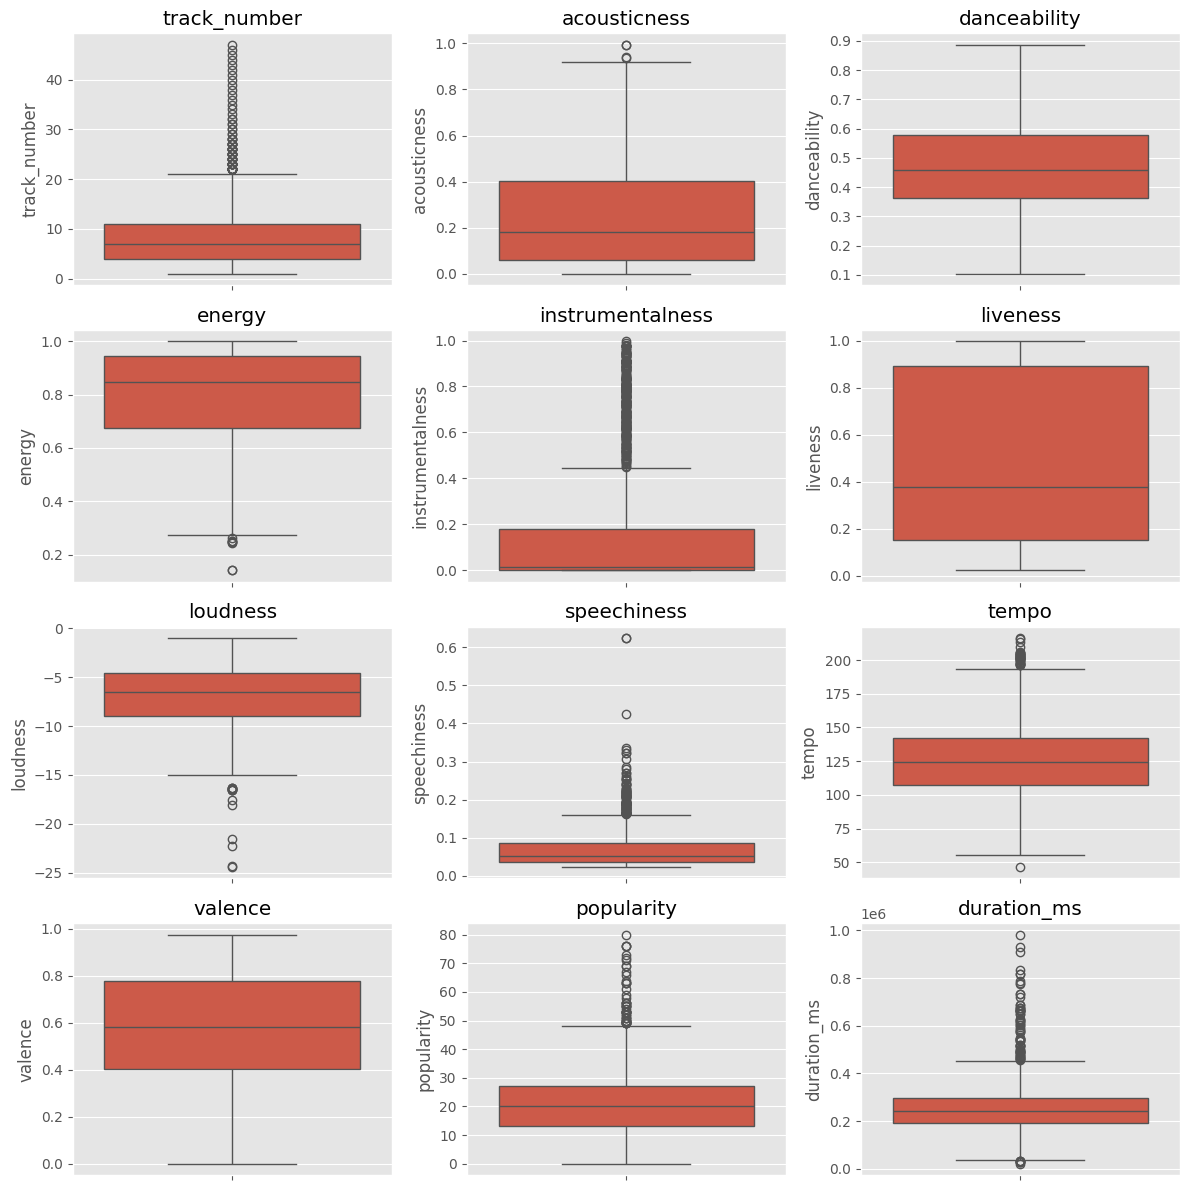

In [366]:
import seaborn as sns

fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

numerical_cols = df.select_dtypes(include="number").columns
for i, col in enumerate(numerical_cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

We can see some outliers in some of the graphs. Some of those are really popular songs like "Paint it Black", or long songs like live versions, songs that are instrumental, or likely intros that are mostly spoken.

In [367]:
# Shortest songs
shortest = df.nsmallest(10, 'duration_ms')[['name', 'duration_ms']]
shortest['duration_sec'] = shortest.duration_ms / 1000
display(shortest)

,name,duration_ms,duration_sec
546,Show Intro - Live,21000,21.000
839,Intro (Take The A Train) - Live / Remastered 2009,27293,27.293
739,Continental Drift - Live,27693,27.693
756,Continental Drift - Live / Remastered 2009,28266,28.266
553,Charlie's Intro To Little Red Rooster - Live,32946,32.946
807,Key To The Highway - Piano Instrumental,33466,33.466
818,Key To The Highway - Piano Instrumental/Remastered 2009,33466,33.466
547,Everybody Needs Somebody To Love - Live,35920,35.920
422,Intro - Live,48000,48.000
850,Outro - Star Spangled Banner - Live / Remastered 2009,48266,48.266


Some of the top 10 shortest songs are intros, with the lowest one being only 21 seconds, but these may be listened to by some, so I will keep them.

In [368]:
# Longest songs
longest = df.nlargest(10, 'duration_ms')[['name', 'duration_ms']]
longest['duration_min'] = longest.duration_ms / (1000 * 60)
display(longest)

,name,duration_ms,duration_min
220,Miss You - Live,981866,16.364433
460,Midnight Rambler - Live,929457,15.490950
537,Miss You - Live,907373,15.122883
482,Miss You - Live,831960,13.866000
297,Miss You - Live,815887,13.598117
325,Miss You - Live,815887,13.598117
1175,Midnight Rambler - Live At University Of Leeds / 1971,789240,13.154000
8,Midnight Rambler - Live,781173,13.019550
183,"Midnight Rambler - Live / Forest National Arena, Brussels / 17/10/73",773226,12.887100
111,Midnight Rambler - Live,734706,12.245100


The top 10 longest songs are live songs, but these are also songs listened to by users, so I will also keep them.

#### Verify all 0-1 columns are actually 0-1

In [369]:
zero_one_columns = ["acousticness", "danceability", "energy", "instrumentalness", "liveness", "speechiness", "valence"]

df[zero_one_columns].max()

acousticness        0.994
danceability        0.887
energy              0.999
instrumentalness    0.996
liveness            0.998
speechiness         0.624
valence             0.974
dtype: float64

In [370]:
df[zero_one_columns].min()

acousticness        0.000009
danceability        0.104000
energy              0.141000
instrumentalness    0.000000
liveness            0.021900
speechiness         0.023200
valence             0.000000
dtype: float64

All columns that are measured from 0 to 1 are within their bounds.

### <u>Refine the data for further processing based on your findings</u>

In [371]:
# Convert duration from milliseconds to minutes
df['duration_min'] = df['duration_ms'] / (60 * 1000)
df.drop(columns=['duration_ms'], inplace=True)
df[['name', 'duration_min']].sort_values('duration_min')

,name,duration_min
546,Show Intro - Live,0.350000
839,Intro (Take The A Train) - Live / Remastered 2009,0.454883
739,Continental Drift - Live,0.461550
756,Continental Drift - Live / Remastered 2009,0.471100
553,Charlie's Intro To Little Red Rooster - Live,0.549100
...,...,...
325,Miss You - Live,13.598117
482,Miss You - Live,13.866000
537,Miss You - Live,15.122883
460,Midnight Rambler - Live,15.490950


The duration column is more readable as a minutes column.

In [372]:
# Create a release_year column for processing by year
df['release_date'] = pd.to_datetime(df.release_date)
df['release_year'] = df.release_date.dt.year

Extracting a release year column will help with looking for patterns over time.

In [373]:
df.drop(columns=['track_number', 'id', 'uri'], inplace=True)

These columns aren't relevant for grouping songs or finding popular albums.

### <u>Perform exploratory data analysis and feature engineering</u>

##### Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album

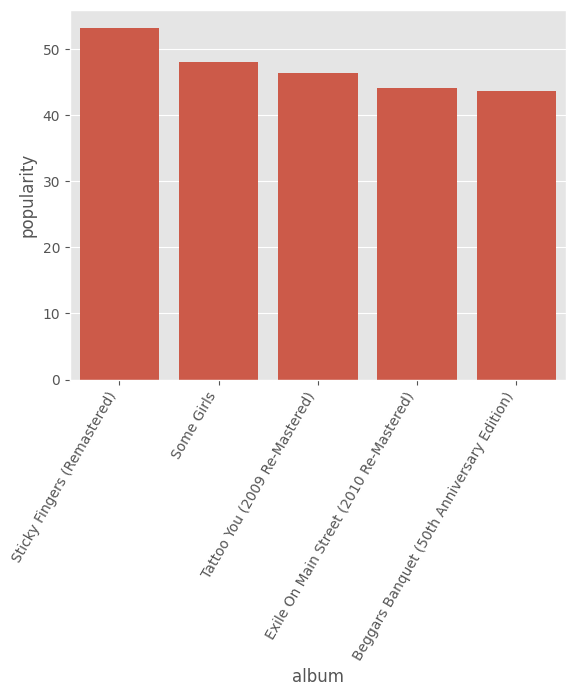

In [374]:
import seaborn as sns

popular = df.groupby('album')['popularity'].mean().sort_values(ascending=False).head(5)

sns.barplot(popular.reset_index(), x='album', y='popularity')
plt.xticks(rotation=60, ha='right')
plt.show()


If we sort by average popularity of the songs in each album, the two albums with highest average popularity are
"**Sticky Fingers (Remastered)**" and "**Some Girls**"

Songs with popularity >= 40 have percentile 93.


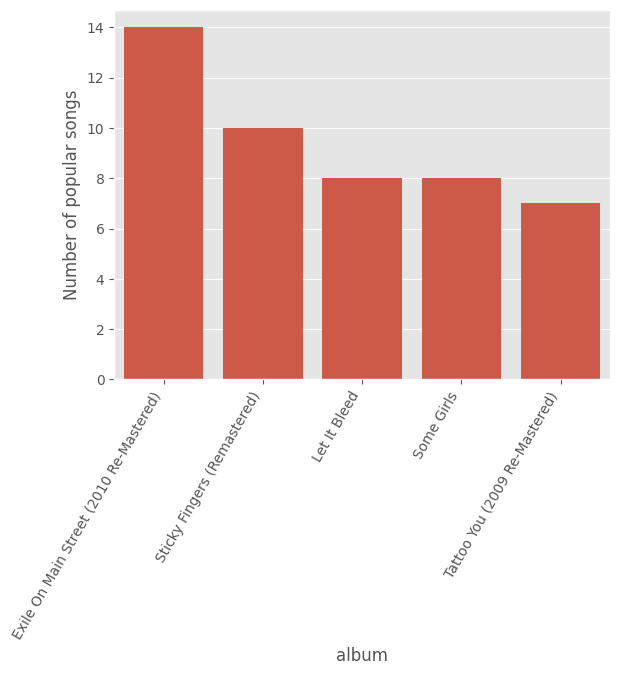

In [375]:
popularity_threshold = 40
df['is_popular'] = df['popularity'] >= popularity_threshold

# Calculate percentile
print(f'Songs with popularity >= {popularity_threshold} have percentile {(df["popularity"] <= popularity_threshold).mean() * 100 :.0f}.')

popular_count = df.groupby('album')['is_popular'].sum().sort_values(ascending=False).reset_index().head(5)

sns.barplot(popular_count, x='album', y='is_popular')
plt.ylabel('Number of popular songs')
plt.xticks(rotation=60, ha='right')
plt.show()

If we consider popular songs as songs with popularity greater than or equal to 40, which are equivalent to songs in at least the 93rd percentile of popularity, we can see that "**Exile On Main Street (2010 Re-Mastered)**" and "**Sticky Fingers (Remastered)**" are the two albums with most popular songs.

##### Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns

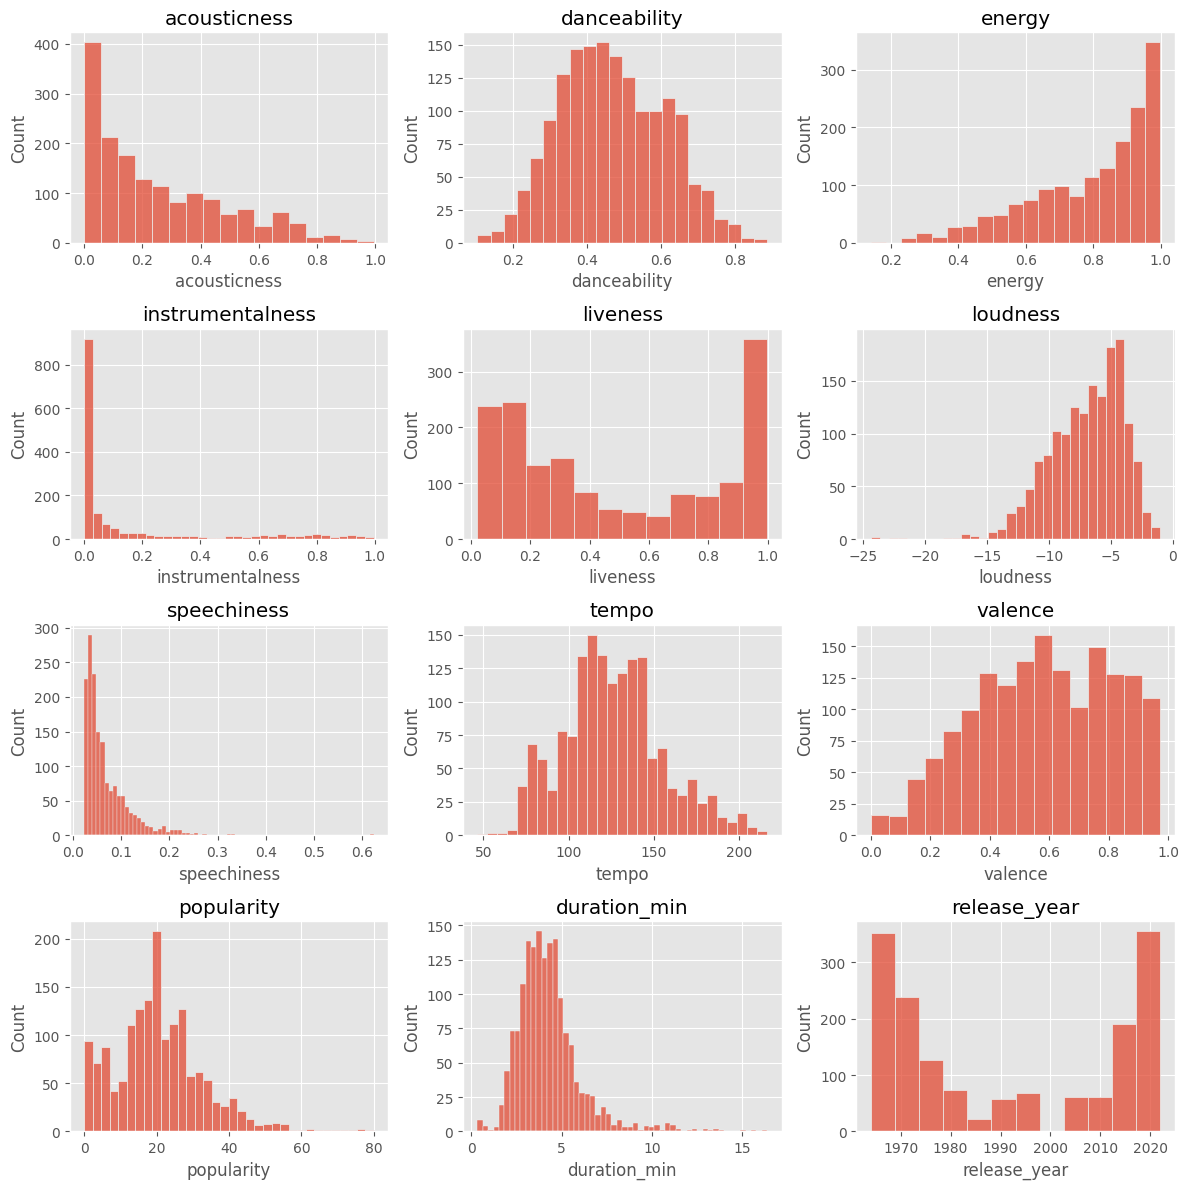

In [376]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

numerical_cols = df.select_dtypes(include="number").columns
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

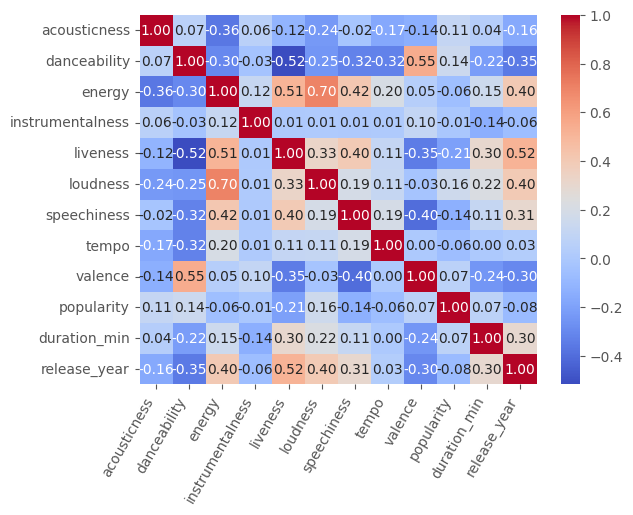

In [377]:
correlation_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=60, ha='right')
plt.show()

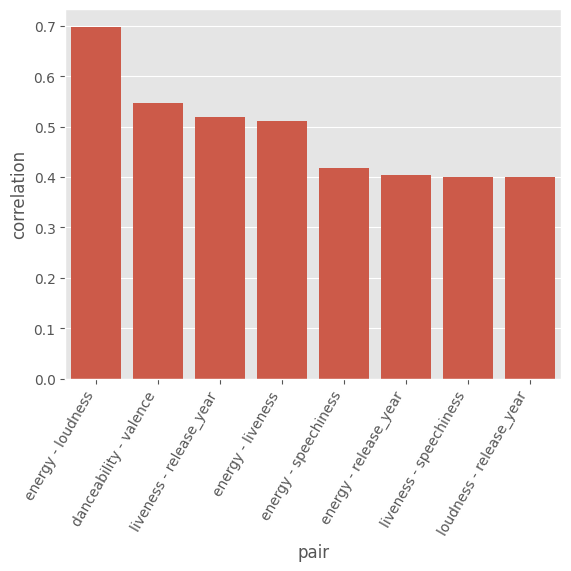

In [378]:
# Find highest correlations between any two features
correlation_matrix = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
pairs = correlation_matrix.where(mask).stack()
highest_correlations = pairs.nlargest(8)
highest_correlations = highest_correlations.reset_index()
highest_correlations['pair'] = highest_correlations['level_0'] + ' - ' + highest_correlations['level_1']
highest_correlations.rename(columns={0: "correlation"}, inplace=True)

sns.barplot(x=highest_correlations.pair, y=highest_correlations.correlation)
plt.xticks(rotation=60, ha='right')
plt.show()

From the correlation matrix, the highest correlations are shown in the bar plot. We can see some significant correlations from this plot.

##### Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved

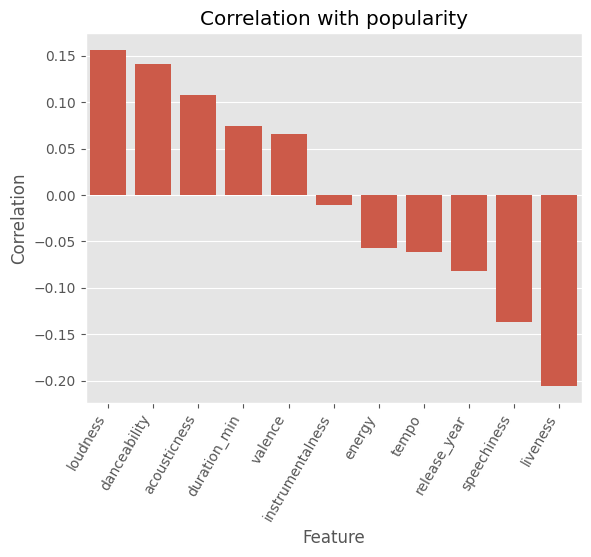

In [379]:
popularity_correlations = (
    df[numerical_cols]
    .corr()["popularity"]
    .drop("popularity")
    .sort_values(ascending=False)
)

sns.barplot(x=popularity_correlations.index, y=popularity_correlations.values)
plt.xticks(rotation=60, ha='right')
plt.title('Correlation with popularity')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.show()

Popularity is not highly correlated with anything. The highest positive correlation is with loudness at around 0.16 and the highest negative correlation is with liveness at -0.21.

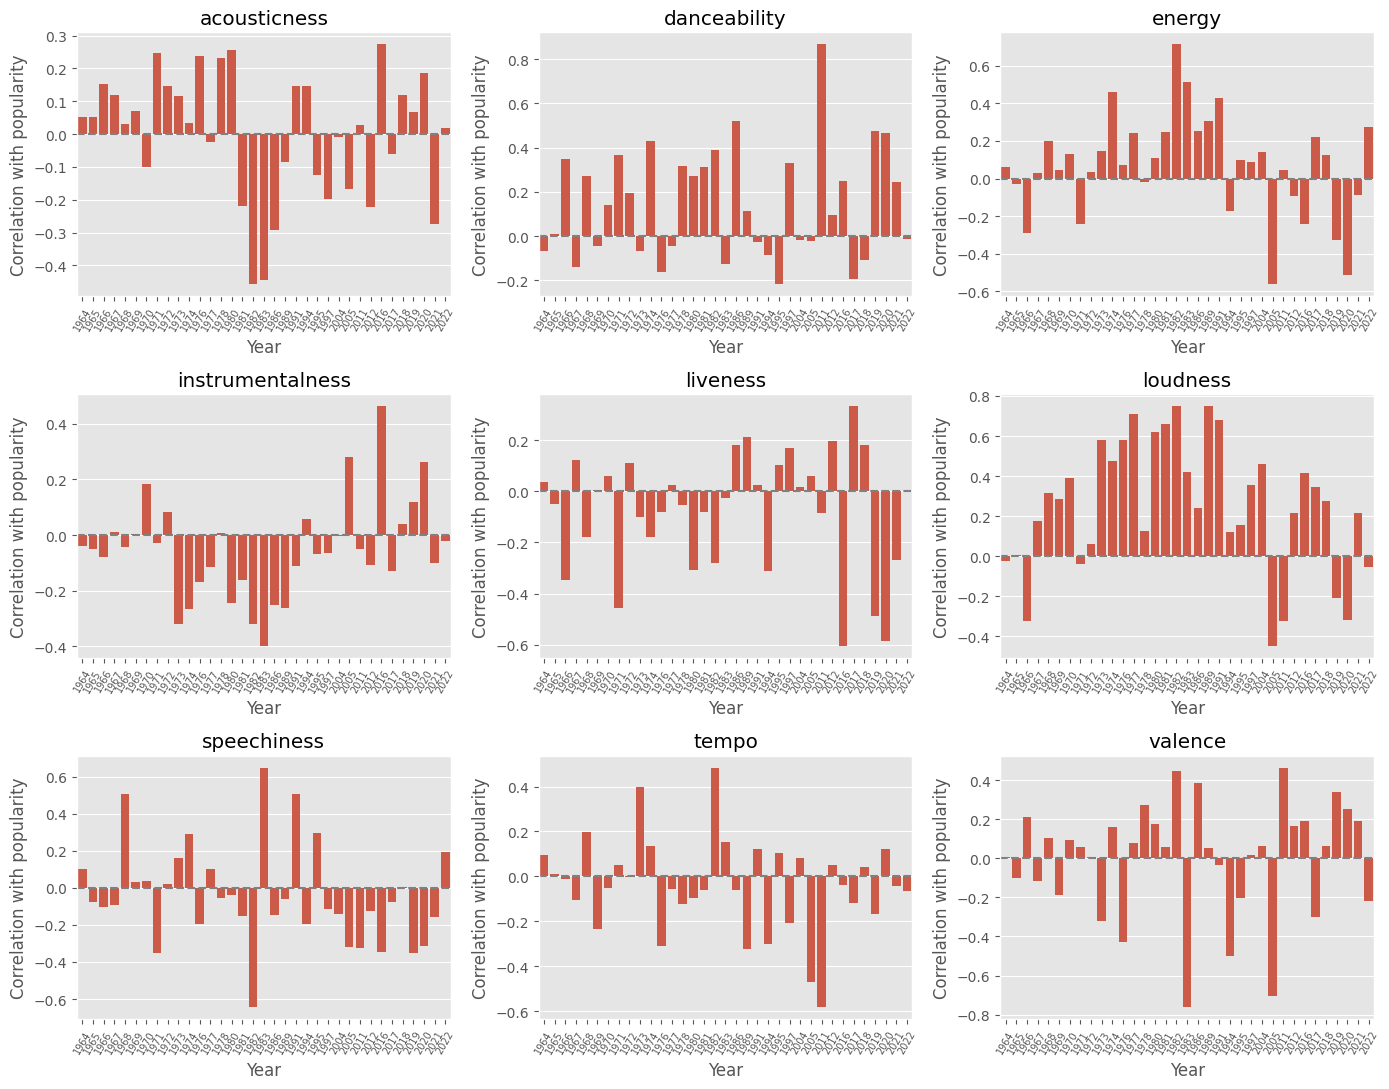

In [380]:
features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 
            'speechiness', 'tempo', 'valence']

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for i, feature in enumerate(features):
    yearly_corr = df.groupby("release_year").apply(lambda g: g[feature].corr(g["popularity"]), include_groups=False).dropna()

    sns.barplot(x=yearly_corr.index, y=yearly_corr.values, ax=axes[i])
    axes[i].axhline(0, color='gray', ls='--')
    axes[i].set_title(feature)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Correlation with popularity")
    axes[i].tick_params(axis="x", rotation=60, labelsize=7)

plt.tight_layout()
plt.show()

The correlation between each feature and popularity tends to vary each year.

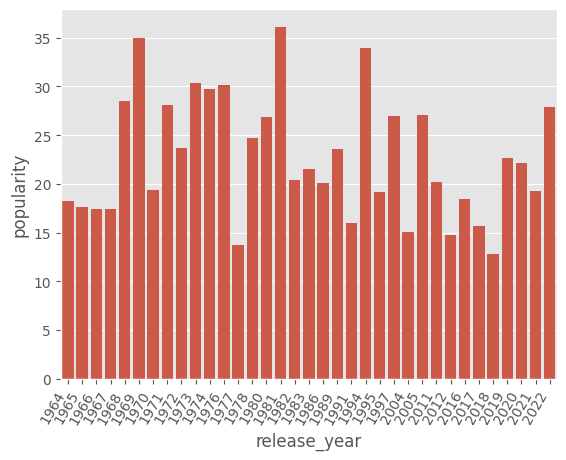

In [381]:
yearly_popularity = df.groupby('release_year')['popularity'].mean()
yearly_popularity = yearly_popularity.reset_index()

sns.barplot(yearly_popularity, x='release_year', y='popularity')
plt.xticks(rotation=60, ha='right')
plt.show()

Average popularity has oscillated between around 14 to 35 over the years.

##### Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations

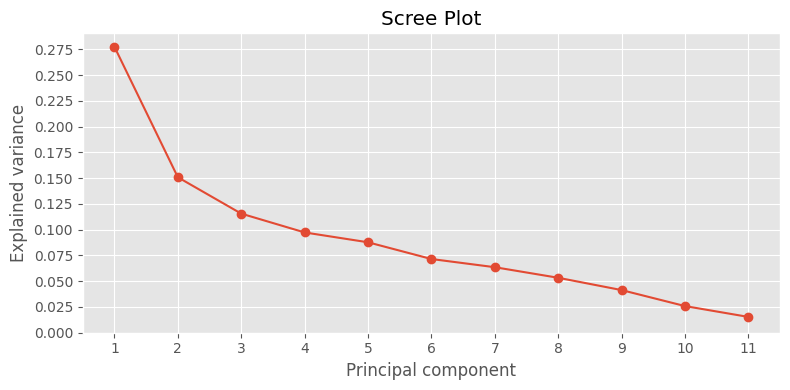

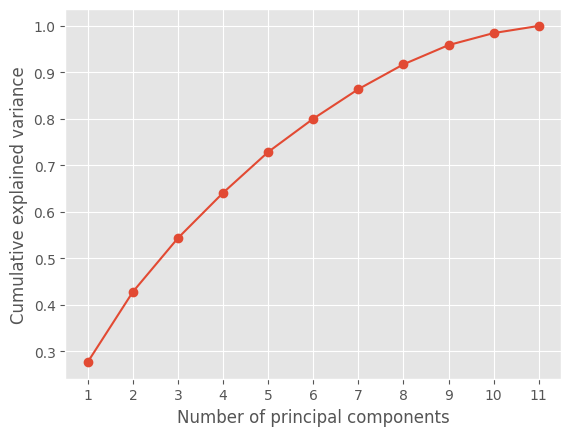

In [382]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[['acousticness', 'danceability','energy', 'instrumentalness', 'liveness', 'loudness', 
        'speechiness', 'tempo', 'valence', 'popularity', 'duration_min']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1), 
    pca.explained_variance_ratio_, 
    marker='o'
)
plt.xlabel('Principal component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1, 1))
plt.ylabel('Explained variance')
plt.yticks(np.arange(0, .3, .025))
plt.title('Scree Plot')
plt.tight_layout()
plt.show()

# Cumulative explained variance
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_), 
    marker='o'
)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.show()

Applying PCA does not seem to significantly reduce dimensionality. The Scree Plot shows that the first component only captures about 28% of the variance, and each following one captures significantly less. The second plot shows that it would take 6 components to capture 80% of the variance, and 8 components to capture about 91% of the variance, which is not much of a gain from directly using all 11.

My goal is to create accurate cohorts of songs. PCA only results in moderate dimensionality reduction, and the current dataset is not too large, so I will choose to apply clustering techniques without PCA.

If we expanded this to a larger dataset such as Spotify's entire music library, applying PCA with 6-8 principal components would have benefits such as compressing the dataset to take up less space, and being able to run the clustering algorithms on it faster.

### <u>Perform cluster analysis</u>

##### Identify the right number of clusters

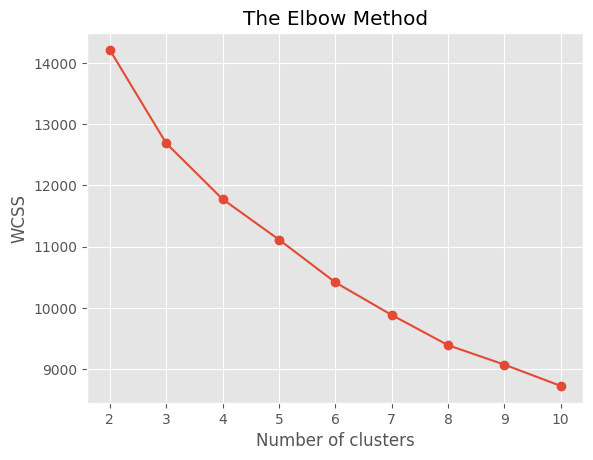

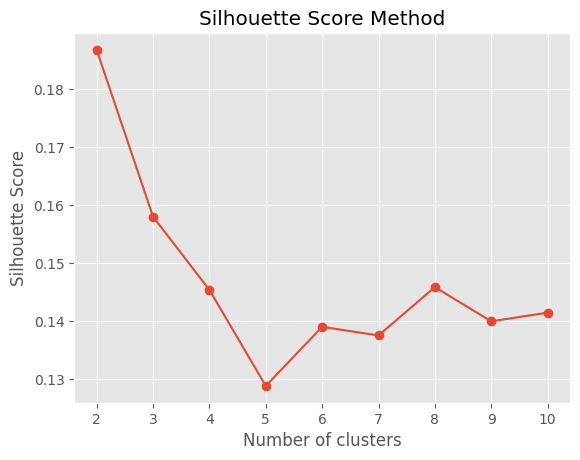

In [383]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

max_k = 10  # Maximum number of clusters to try
wcss = []
silhouette_scores = []


for k in range(2, max_k + 1):
    model = KMeans(n_clusters=k, n_init=10, init='k-means++', random_state=42)
    model.fit(X_scaled)

    # WCSSs for the elbow method
    wcss.append(model.inertia_)

    # For the silhouette score method
    score = silhouette_score(X_scaled, model.labels_)
    silhouette_scores.append(score)

# Elbow plot
plt.plot(range(2, max_k + 1), wcss, marker='o')
plt.xticks(range(2, max_k + 1))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('The Elbow Method')
plt.show()

# Silhouette Score plot
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.show()

The plots show that the songs do not form sharp clusters. They are more uniformly distributed, so there is no clear optimal amount of clusters. Picking 2 clusters would split the whole dataset into just 2 cohorts, which might not give meaningful recommendations to users. The silhouette score shows a local peak at 8, which suggests that 8 may be a better number of clusters with more meaningful cohorts of songs.

##### Use appropriate clustering algorithms

In [384]:
# K-means with k = 8
num_cohorts = 8
model = KMeans(num_cohorts, n_init=10, init='k-means++', random_state=42)
clusters = model.fit_predict(X_scaled)
df['cohort'] = clusters + 1

df.cohort.value_counts()

cohort
4    323
8    272
5    267
3    208
1    165
6    149
7    139
2     87
Name: count, dtype: int64

Each cohort has between 87 to 323 songs.

##### Define each cluster based on the features

Cohort feature averages:


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min
cohort,,,,,,,,,,,
1,0.253,0.508,0.842,0.758,0.424,-6.598,0.049,124.509,0.753,21.630,3.458
2,0.214,0.381,0.875,0.109,0.846,-5.841,0.090,129.899,0.435,18.782,9.405
3,0.569,0.450,0.555,0.091,0.322,-9.097,0.046,105.052,0.382,25.197,4.641
4,0.154,0.410,0.914,0.051,0.843,-5.484,0.076,119.913,0.520,16.458,4.475
5,0.227,0.623,0.636,0.086,0.219,-10.089,0.047,114.781,0.746,15.697,3.122
6,0.242,0.309,0.967,0.280,0.857,-5.156,0.178,147.456,0.327,17.550,4.328
7,0.210,0.344,0.733,0.076,0.382,-8.200,0.061,178.333,0.544,16.755,3.624
8,0.181,0.557,0.861,0.071,0.255,-5.008,0.053,121.906,0.750,31.522,4.169


Overall feature averages:


,average
acousticness,0.250
danceability,0.469
energy,0.792
instrumentalness,0.164
liveness,0.492
loudness,-6.972
speechiness,0.070
tempo,126.082
valence,0.582
popularity,20.788


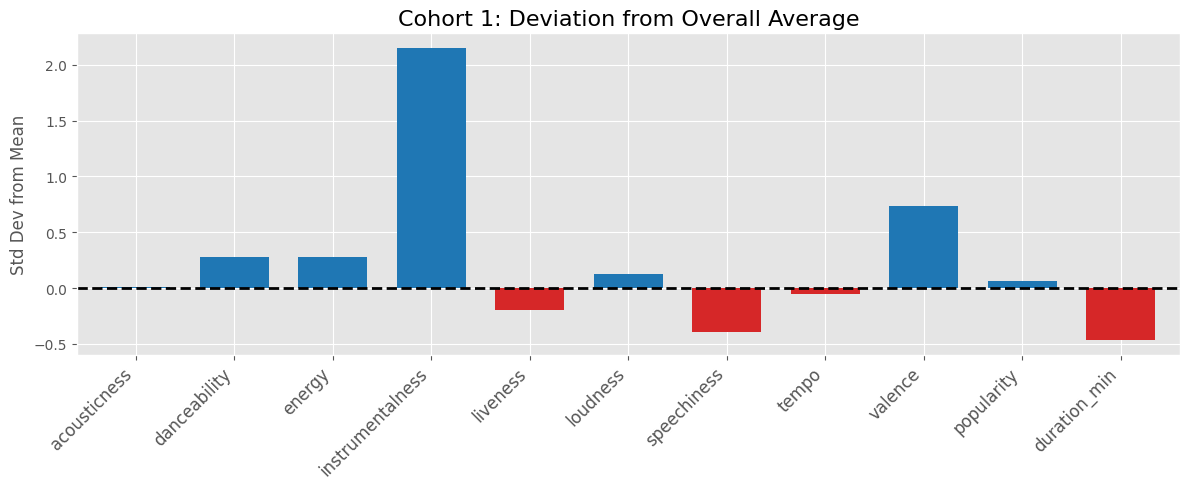

 Cohort 1 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
1468,The Last Time - Mono Version,Out Of Our Heads,0.14,0.33,0.92,0.84,0.77,-5.22,0.06,167.97,0.44,50,3.69,1965
1040,Rip This Joint,Exile On Main Street (2010 Re-Mastered),0.12,0.55,0.95,0.84,0.30,-2.96,0.04,98.04,0.91,49,2.39,1972
1095,Happy,Exile On Main Street (Deluxe Version),0.36,0.56,0.90,0.94,0.54,-3.47,0.03,131.71,0.96,49,3.08,1972
1121,Sway - 2009 Mix,Sticky Fingers (Remastered),0.22,0.33,0.90,0.74,0.41,-3.44,0.04,144.94,0.54,46,3.88,1971
1041,Shake Your Hips,Exile On Main Street (2010 Re-Mastered),0.69,0.37,0.79,0.83,0.20,-7.05,0.06,180.50,0.76,43,2.98,1972
1050,Ventilator Blues,Exile On Main Street (2010 Re-Mastered),0.60,0.62,0.68,0.72,0.50,-5.20,0.03,133.45,0.79,43,3.41,1972
899,Respectable - Remastered,Some Girls,0.12,0.45,0.99,0.88,0.07,-2.82,0.05,152.11,0.88,42,3.12,1978
1020,100 Years Ago - Remastered,Goats Head Soup (Remastered 2009),0.73,0.41,0.80,0.76,0.64,-4.33,0.05,124.33,0.62,42,3.97,1973
1053,All Down The Line,Exile On Main Street (2010 Re-Mastered),0.39,0.52,0.97,0.98,0.78,-3.04,0.06,140.22,0.82,42,3.82,1972
243,Tumbling Dice,Honk (Deluxe),0.46,0.62,0.90,0.58,0.29,-4.58,0.04,110.96,0.79,41,3.77,2019



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




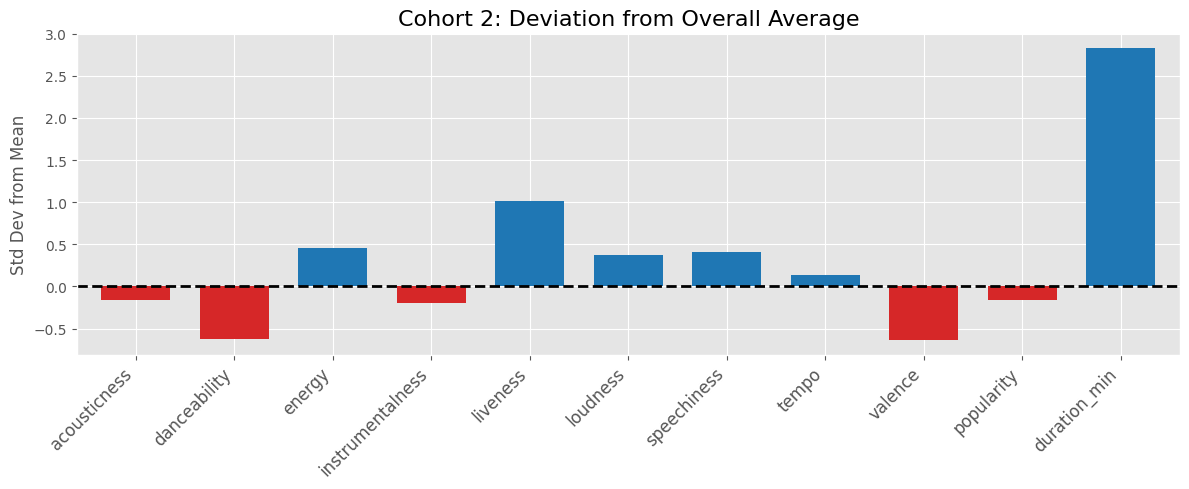

 Cohort 2 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
568,Baby Please Don't Go - Live,Live At The Checkerboard Lounge,0.11,0.36,0.88,0.00,0.95,-6.60,0.11,155.18,0.62,37,11.02,2012
668,Gimme Shelter - Live Licks Tour - 2009 Re-Mastered Digital Version,Live Licks,0.27,0.39,0.98,0.00,0.72,-2.63,0.07,119.67,0.24,36,6.84,2004
1413,Going Home,Aftermath,0.07,0.50,0.52,0.08,0.22,-13.09,0.05,130.68,0.47,35,11.22,1966
762,You Can't Always Get What You Want - Live / Remastered 2009,Flashpoint,0.45,0.32,0.91,0.00,0.42,-3.43,0.12,83.01,0.40,33,7.43,1991
8,Midnight Rambler - Live,Licked Live In NYC,0.42,0.27,0.94,0.04,0.96,-6.02,0.12,139.45,0.28,30,13.02,2022
462,Gimme Shelter - Live,Havana Moon (Live),0.05,0.46,0.87,0.03,0.68,-4.21,0.03,114.64,0.24,30,8.08,2016
1207,"Midnight Rambler - Live From Madison Square Garden, New York/1969",Get Yer Ya-Ya's Out! The Rolling Stones In Concert (40th Anniversary Edition),0.26,0.43,0.70,0.36,0.98,-9.35,0.08,134.70,0.48,30,9.07,1970
453,Out Of Control - Live,Havana Moon (Live),0.43,0.48,0.79,0.02,0.95,-5.70,0.05,118.92,0.50,29,7.22,2016
13,Gimme Shelter - Live,Licked Live In NYC,0.42,0.36,0.98,0.00,0.98,-5.10,0.10,119.78,0.14,28,7.17,2022
467,(I Can't Get No) Satisfaction - Live,Havana Moon (Live),0.01,0.34,0.97,0.63,0.34,-4.16,0.08,131.16,0.32,28,10.48,2016



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




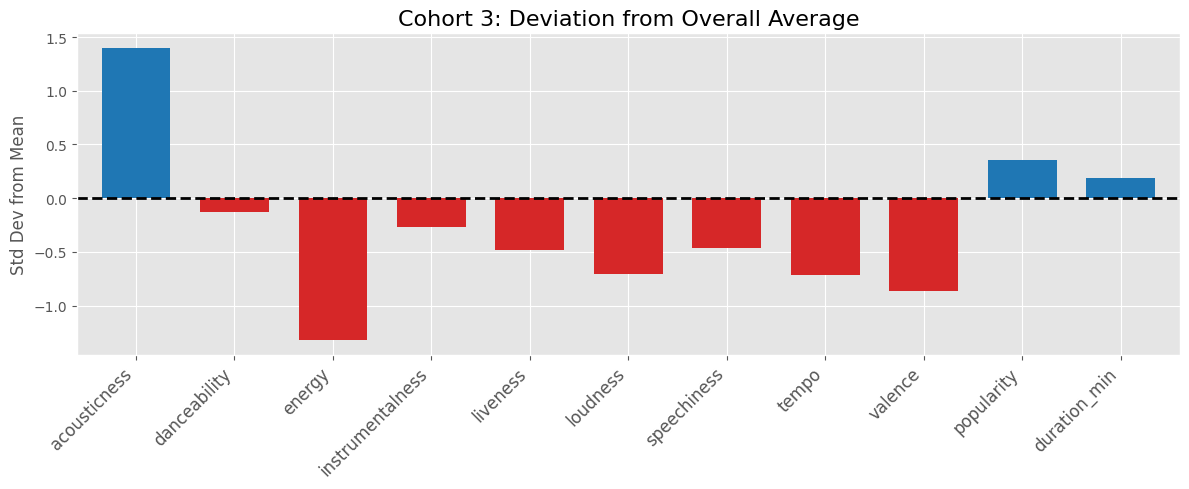

 Cohort 3 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
1023,Angie,Goats Head Soup (Remastered 2009),0.67,0.43,0.55,0.00,0.10,-6.13,0.03,136.30,0.41,71,4.53,1973
1122,Wild Horses - 2009 Mix,Sticky Fingers (Remastered),0.69,0.43,0.39,0.01,0.08,-6.52,0.03,139.51,0.16,69,5.70,1971
1256,You Can't Always Get What You Want,Let It Bleed,0.64,0.32,0.62,0.00,0.25,-9.69,0.06,86.33,0.47,67,7.48,1969
1357,Ruby Tuesday,Between The Buttons,0.83,0.52,0.55,0.00,0.17,-10.77,0.03,104.58,0.52,63,3.27,1967
1450,As Tears Go By - Mono Version,December’s Children (And Everybody’s),0.72,0.33,0.28,0.00,0.18,-11.04,0.03,112.78,0.37,56,2.75,1965
1475,Play With Fire - Mono Version,Out Of Our Heads,0.18,0.58,0.43,0.00,0.17,-9.60,0.03,108.74,0.09,56,2.22,1965
870,Heaven - Remastered,Tattoo You (2009 Re-Mastered),0.22,0.62,0.46,0.04,0.28,-9.29,0.04,114.50,0.12,55,4.37,1981
989,Fool To Cry - Remastered 2009,Black And Blue (Remastered 2009),0.89,0.44,0.45,0.05,0.11,-7.43,0.04,67.85,0.24,53,5.09,1976
1129,Moonlight Mile - 2009 Mix,Sticky Fingers (Remastered),0.57,0.42,0.50,0.09,0.10,-6.45,0.03,130.53,0.24,53,5.95,1971
1141,Wild Horses - Acoustic Version,Sticky Fingers (Deluxe),0.56,0.38,0.39,0.00,0.10,-7.87,0.03,147.66,0.18,50,5.79,1971



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




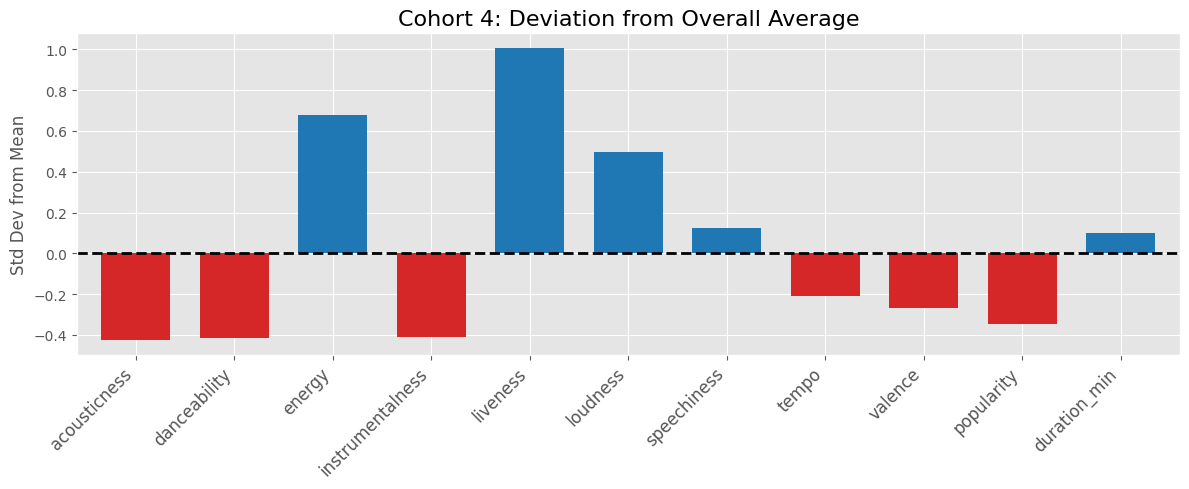

 Cohort 4 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
663,Start Me Up - Live Licks Tour - 2009 Re-Mastered Digital Version,Live Licks,0.14,0.46,0.99,0.02,0.98,-2.16,0.10,130.30,0.52,37,4.04,2004
665,Angie - Live Licks Tour - 2009 Re-Mastered Digital Version,Live Licks,0.20,0.47,0.80,0.00,0.93,-4.69,0.03,79.82,0.40,36,3.49,2004
669,(I Can't Get No) Satisfaction - Live Licks Tour / Remastered 2009,Live Licks,0.03,0.29,0.98,0.00,0.96,-2.83,0.06,142.11,0.53,36,4.92,2004
274,Wild Horses - Live At London Stadium,Honk (Deluxe),0.23,0.42,0.73,0.00,0.63,-4.23,0.03,80.47,0.34,35,4.82,2019
1,Street Fighting Man - Live,Licked Live In NYC,0.44,0.33,0.96,0.23,0.96,-4.80,0.08,131.46,0.32,34,4.22,2022
759,Miss You - Live / Remastered 2009,Flashpoint,0.18,0.58,0.98,0.05,0.99,-3.50,0.08,121.23,0.63,34,5.91,1991
4,Don’t Stop - Live,Licked Live In NYC,0.40,0.30,0.97,0.06,0.97,-5.10,0.09,130.53,0.21,32,5.09,2022
666,Honky Tonk Women - Live Licks Tour - 2009 Re-Mastered Digital Version,Live Licks,0.36,0.48,0.98,0.00,0.97,-2.91,0.09,112.47,0.51,32,3.40,2004
767,Sympathy For The Devil - Live / Remastered 2009,Flashpoint,0.63,0.58,0.99,0.06,0.99,-3.46,0.10,110.28,0.34,32,5.58,1991
5,Monkey Man - Live,Licked Live In NYC,0.28,0.34,0.96,0.12,0.74,-5.54,0.09,101.63,0.12,31,4.07,2022



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




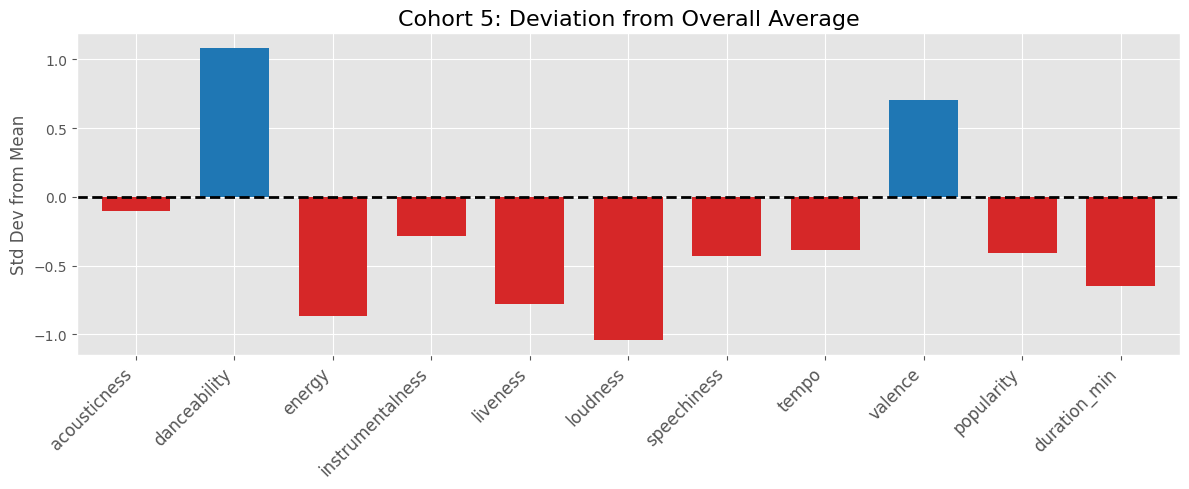

 Cohort 5 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
1406,Under My Thumb,Aftermath,0.30,0.73,0.49,0.20,0.09,-13.57,0.04,126.99,0.80,64,3.69,1966
1428,Mother's Little Helper,Aftermath (UK Version),0.02,0.58,0.55,0.00,0.23,-11.68,0.03,101.69,0.72,52,2.75,1966
1536,Little Red Rooster - Mono Version,"The Rolling Stones, Now!",0.07,0.72,0.43,0.03,0.10,-11.69,0.04,109.37,0.67,45,3.10,1965
1567,It's All Over Now - Mono Version,12 X 5,0.02,0.60,0.69,0.00,0.33,-10.73,0.03,99.09,0.76,44,3.44,1964
1250,Country Honk,Let It Bleed,0.63,0.53,0.76,0.00,0.35,-10.99,0.05,120.96,0.89,40,3.12,1969
1251,Live With Me,Let It Bleed,0.01,0.68,0.63,0.05,0.08,-10.00,0.04,129.59,0.95,39,3.55,1969
1404,Stupid Girl,Aftermath,0.17,0.69,0.80,0.49,0.15,-11.92,0.06,130.88,0.90,39,2.92,1966
1259,Dear Doctor - 50th Anniversary Edition,Beggars Banquet (50th Anniversary Edition),0.10,0.60,0.45,0.00,0.14,-8.27,0.03,126.45,0.42,37,3.37,1968
1051,I Just Want To See His Face,Exile On Main Street (2010 Re-Mastered),0.69,0.65,0.54,0.58,0.20,-14.70,0.04,78.02,0.88,36,2.88,1972
1407,Doncha Bother Me,Aftermath,0.52,0.54,0.81,0.00,0.11,-11.19,0.06,123.27,0.78,36,2.69,1966



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




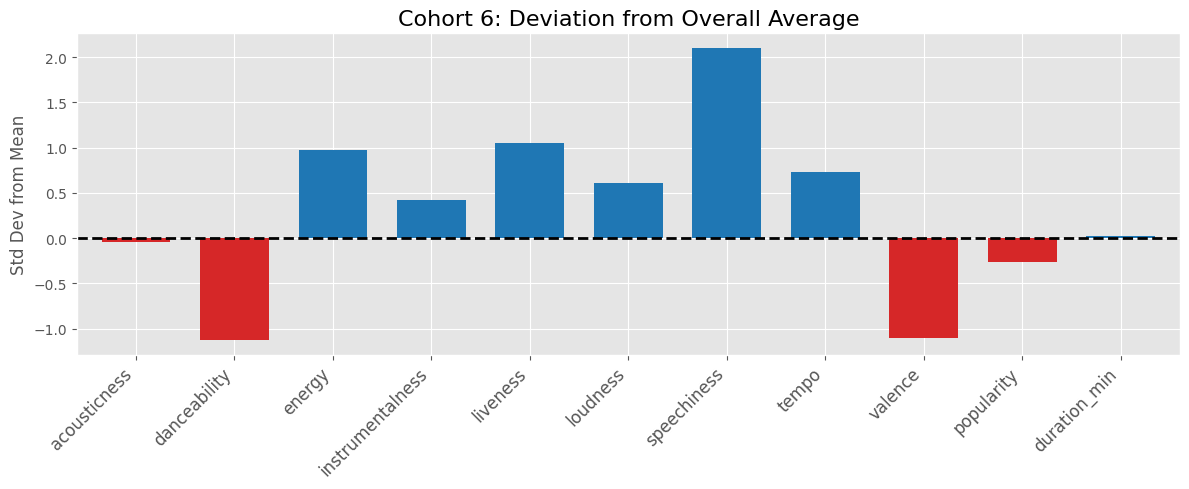

 Cohort 6 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
697,Like A Rolling Stone - Live / Remastered 2009,Stripped,0.02,0.21,0.94,0.00,0.95,-3.93,0.12,205.53,0.33,43,5.65,1995
162,Scarlet,Goats Head Soup (Deluxe),0.04,0.48,0.95,0.37,0.25,-3.39,0.18,172.67,0.64,37,3.74,2020
897,Lies - Remastered,Some Girls,0.44,0.38,1.00,0.95,0.62,-1.57,0.19,162.43,0.56,37,3.19,1978
2,Start Me Up - Live,Licked Live In NYC,0.42,0.39,0.97,0.40,0.96,-4.94,0.12,130.07,0.31,34,4.39,2022
766,Paint It Black - Live / Remastered 2009,Flashpoint,0.01,0.27,0.96,0.69,0.99,-3.84,0.12,160.80,0.35,33,4.03,1991
3,If You Can't Rock Me - Live,Licked Live In NYC,0.57,0.37,0.98,0.00,0.90,-5.54,0.19,132.99,0.15,32,5.10,2022
9,Tumbling Dice - Live,Licked Live In NYC,0.40,0.31,0.94,0.08,0.97,-5.07,0.13,119.78,0.19,29,5.56,2022
769,Jumpin' Jack Flash - Live / Remastered 2009,Flashpoint,0.17,0.27,0.99,0.19,0.98,-3.10,0.22,148.85,0.28,29,4.99,1991
17,Satisfaction - Live,Licked Live In NYC,0.50,0.26,0.98,0.31,0.97,-4.47,0.09,142.46,0.24,28,6.19,2022
770,(I Can't Get No) Satisfaction - Live / Remastered 2009,Flashpoint,0.06,0.36,1.00,0.09,0.51,-3.80,0.20,150.87,0.38,28,6.14,1991



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




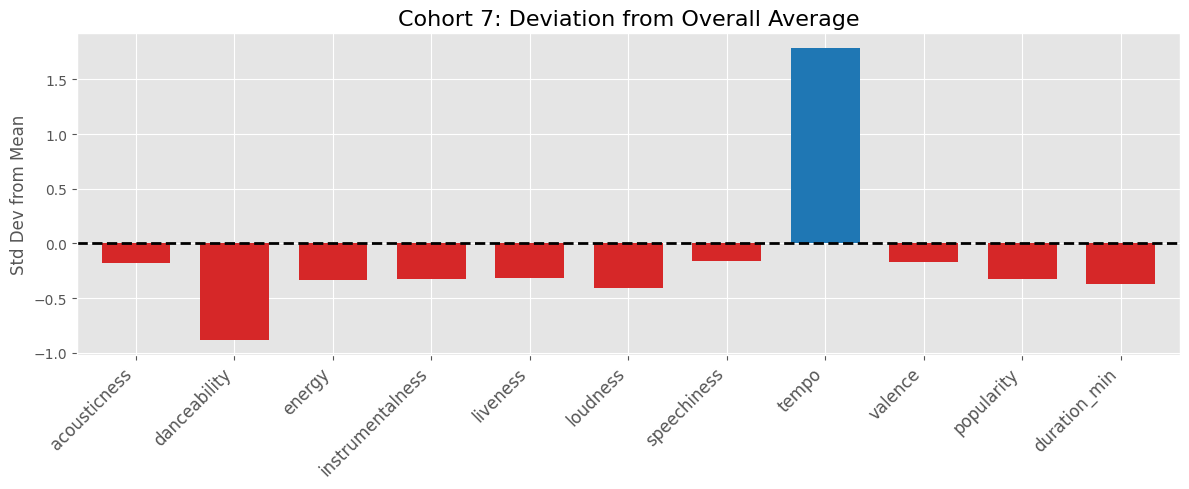

 Cohort 7 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
1565,Time Is On My Side - Mono Version / Organ Intro,12 X 5,0.34,0.23,0.83,0.00,0.07,-7.59,0.14,216.30,0.42,44,2.88,1964
1249,Love In Vain,Let It Bleed,0.28,0.37,0.48,0.00,0.12,-11.80,0.04,184.36,0.30,42,4.32,1969
1231,Love In Vain - Remastered 2019,Let It Bleed (50th Anniversary Edition / Remastered 2019),0.24,0.38,0.48,0.01,0.12,-11.32,0.04,182.54,0.29,41,4.32,1969
1046,Sweet Black Angel,Exile On Main Street (2010 Re-Mastered),0.65,0.50,0.73,0.00,0.11,-7.39,0.04,174.33,0.61,40,2.96,1972
1265,Factory Girl - 50th Anniversary Edition,Beggars Banquet (50th Anniversary Edition),0.20,0.44,0.46,0.00,0.14,-9.74,0.04,177.10,0.45,37,2.17,1968
1371,She Smiled Sweetly,Between The Buttons (UK Version),0.10,0.34,0.30,0.00,0.12,-12.08,0.12,191.57,0.22,36,2.75,1967
449,I Can't Quit You Baby,Blue & Lonesome,0.23,0.33,0.71,0.02,0.07,-5.04,0.05,182.50,0.17,35,5.22,2016
1562,Around And Around,12 X 5,0.46,0.32,0.61,0.00,0.29,-11.86,0.06,185.99,0.75,35,3.05,1964
517,Like A Rolling Stone - Live,Totally Stripped (Live),0.08,0.18,0.87,0.00,0.76,-6.14,0.06,203.24,0.37,34,6.18,2016
173,Scarlet - The Killers & Jacques Lu Cont Remix,Goats Head Soup (Deluxe),0.01,0.47,0.89,0.04,0.11,-9.46,0.04,174.07,0.61,32,3.24,2020



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




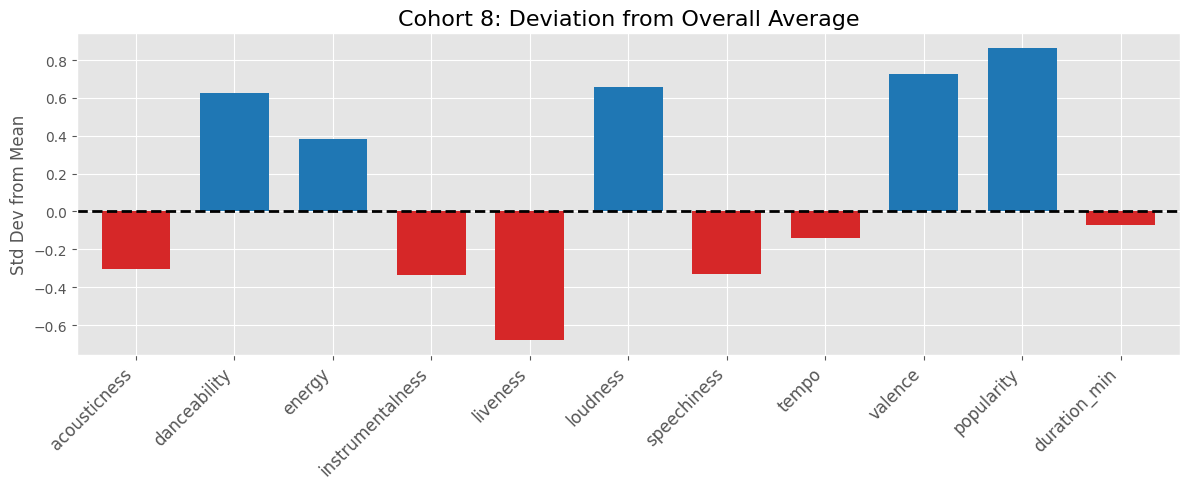

 Cohort 8 sample songs:


,name,album,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_min,release_year
1403,"Paint It, Black",Aftermath,0.05,0.46,0.80,0.00,0.40,-9.27,0.09,158.69,0.61,80,3.37,1966
862,Start Me Up - Remastered 2009,Tattoo You (2009 Re-Mastered),0.04,0.63,0.93,0.14,0.09,-4.14,0.04,122.43,0.97,76,3.55,1981
1248,Gimme Shelter,Let It Bleed,0.45,0.63,0.63,0.04,0.17,-8.28,0.03,118.63,0.49,76,4.51,1969
1472,(I Can't Get No) Satisfaction - Mono Version,Out Of Our Heads,0.04,0.72,0.86,0.03,0.13,-7.89,0.03,136.30,0.93,76,3.71,1965
1257,Sympathy For The Devil - 50th Anniversary Edition,Beggars Banquet (50th Anniversary Edition),0.52,0.70,0.67,0.00,0.06,-9.24,0.21,116.06,0.56,73,6.30,1968
901,Beast Of Burden - Remastered 1994,Some Girls,0.39,0.78,0.88,0.00,0.04,-3.86,0.03,100.63,0.88,72,4.42,1978
893,Miss You - Remastered,Some Girls,0.44,0.80,0.71,0.02,0.34,-4.75,0.04,109.69,0.84,69,4.81,1978
1120,Brown Sugar - 2009 Remaster,Sticky Fingers (Remastered),0.22,0.63,0.93,0.00,0.06,-3.59,0.03,128.61,0.96,66,3.81,1971
1043,Tumbling Dice,Exile On Main Street (2010 Re-Mastered),0.50,0.62,0.91,0.51,0.28,-4.25,0.03,111.01,0.77,63,3.77,1972
1123,Can't You Hear Me Knocking - 2009 Mix,Sticky Fingers (Remastered),0.41,0.55,0.76,0.04,0.16,-5.23,0.04,152.22,0.71,63,7.27,1971



≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈




In [385]:
features = ['acousticness', 'danceability',
       'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness',
       'tempo', 'valence', 'popularity', 'duration_min']

print('Cohort feature averages:')
display(df.groupby('cohort')[features].mean().round(3))

print('Overall feature averages:')
display(pd.DataFrame(df[features].mean()).rename(columns={0: 'average'}).round(3))

df_scaled = pd.DataFrame(X_scaled, columns=features, index=df.index)
df_scaled['cohort'] = df['cohort']
cohort_scaled_means = df_scaled.groupby('cohort')[features].mean()

# Plot deviation of features for each cohort from the overall average, measured in standard deviations
plt.style.use('ggplot')
for i in range(1, num_cohorts + 1):
    fig, ax = plt.subplots(figsize=(12, 5))
    cohort_data = cohort_scaled_means.loc[i]
    
    # Plot
    colors = ['#1f77b4' if val >= 0 else '#d62728' for val in cohort_data]  # blue = above average, red = below average
    cohort_data.plot(kind='bar', ax=ax, color=colors, width=0.7)
    
    # Formatting
    ax.axhline(0, color='black', linewidth=2, linestyle='--')
    ax.set_title(f'Cohort {i}: Deviation from Overall Average', fontsize=16)
    ax.set_ylabel('Std Dev from Mean', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Sample songs
    sample_songs = df[df['cohort']==i].nlargest(10, 'popularity')[['name', 'album', 'acousticness', 'danceability', 'energy', 
            'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_min', 'release_year']].round(2)
    print(f' Cohort {i} sample songs:')
    display(sample_songs)
    print('\n' + '≈' * 180 + '\n\n')

The plots above show how each feature in each cohort compares to the overall average for that feature. Blue bars mean they are above the overall average, and red bars mean below the overall average, measured in standard deviations. This lets us visualize the characteristics of each cohort and get a sense for the types of songs they have.

Based on the plots, we could categorize each cohort as such:
- Cohort 1: Instrumental songs
    - This has the most instrumental songs by a large margin. Customers who like instrumental songs may like many songs from this cohort. It has many popular songs from the 70s.

- Cohort 2: Longer live songs
    - Since live songs tend to have long durations, and this cohort has the longest songs (average ~9 minutes compared to next largest at ~5 minutes), this cohort contains all of the long live songs.

- Cohort 3: Soft acoustic songs
    - These songs have significantly higher acousticness on average, lowest energy, second lowest loudness, low tempo, and second lowest valence, so they are softer songs with a mellow feel and acoustic sound. It contains many popular songs from the 60s and 70s.

- Cohort 4: Shorter live songs
    - This cohort is rougly tied with cohorts 2 and 6 for liveness, so this contains many live songs. Songs in this cohort are shorter, have a lower tempo, and are less acoustic than those in cohort 2. It has many popular songs from the 90s and 2000s.

- Cohort 5: Most danceable songs
    - This cohort has the highest average in danceability. The valence is among the highest, tied with cohorts 1 and 8, suggesting more positive sounding tracks. Loudness and energy are low. It has many popular songs from the 60s.

- Cohort 6: High speechiness songs, mostly live
    - Similar to cohorts 2 and 4 in liveness. Has the highest speechiness out of all cohorts, and more instrumental than the other two cohorts of mostly live songs. It has many recent songs from the 2020s. The speechiness may come from singers speaking during live performances.

- Cohort 7: Highest tempo songs
    - This cohort has the highest tempo songs, averaging at 178 beats per minute, though the songs are on average less danceable and less loud.

- Cohort 8: Most popular songs
    - This cohort gathers highly popular songs, with an average popularity of 31.5. It includes hit tracks like "Paint it, Black" and "(I Can't Get No) Satisfaction". Valence, loudness, danceability, and energy are high for these songs. Liveness is one of the lowest, so there are likely little to no live songs. Acousticness is on the lower end, so these songs likely sound more electronic. It contains all the hits from the 60s and 70s that defined the band's success.

Possible further adjustments to this clustering process might be:
- Separate actual live songs from the rest and possibly perform clustering on those. Always suggest live versions of songs a user likes.
- Keep only one of each truly duplicated song, perhaps only the ones with highest popularity, and keep only the re-mastered versions as those are supposedly better. Some songs may have to be refactored if their popularity is lower for the re-mastered versions.
- Test out different numbers of clusters to see if they form more meaningful cohorts, such as 6 or 10.